<a href="https://colab.research.google.com/github/hikaaru13/PCVK-GANJIL-TUGAS/blob/main/TUGAS_Aplikasi_Pertemuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

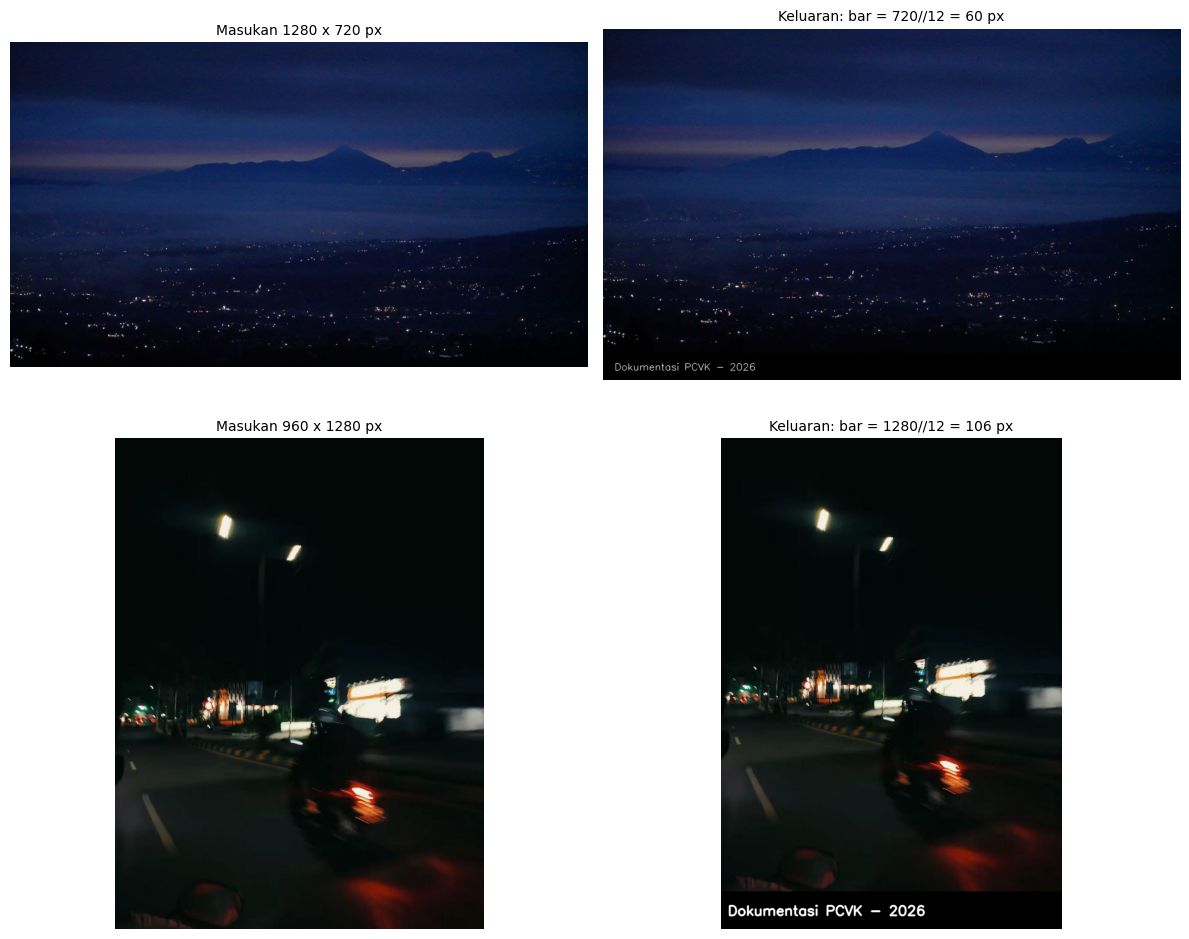

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def label_dokumentasi(image_path, teks):
    img = cv.imread(image_path)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # Tinggi bar 1/12 dari tinggi gambar
    bar_height = h // 12

    # Buat kanvas baru (hitam) dengan tambahan ruang di bawah
    canvas = np.zeros((h + bar_height, w, 3), dtype=np.uint8)
    canvas[:h, :] = img_rgb

    # Pengaturan ukuran teks adaptif
    font_scale = h / 1000
    thickness = max(1, int(h / 400))

    # Mengambil ukuran teks untuk meratakan secara vertikal di tengah bar
    (text_w, text_h), _ = cv.getTextSize(teks, cv.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
    text_x = int(w * 0.02)
    text_y = h + (bar_height + text_h) // 2

    cv.putText(canvas, teks, (text_x, text_y), cv.FONT_HERSHEY_SIMPLEX,
               font_scale, (255, 255, 255), thickness, cv.LINE_AA)

    return img_rgb, canvas, w, h, bar_height

# --- MEMANGGIL 2 GAMBAR SEKALIGUS ---
# Ganti dengan path file yang sesuai di Drive Anda
img_ori_1, img_hasil_1, w1, h1, bar1 = label_dokumentasi('/content/drive/MyDrive/PCVK/LANSKAPE.jpeg', 'Dokumentasi PCVK - 2026')
img_ori_2, img_hasil_2, w2, h2, bar2 = label_dokumentasi('/content/drive/MyDrive/PCVK/POTRAIT.jpeg', 'Dokumentasi PCVK - 2026')

# Membuat figure grid 2 baris x 2 kolom
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Baris 1: Pengujian Gambar Lanskap
axes[0, 0].imshow(img_ori_1)
axes[0, 0].set_title(f'Masukan {w1} x {h1} px', fontsize=10)
axes[0, 0].axis('off')

axes[0, 1].imshow(img_hasil_1)
axes[0, 1].set_title(f'Keluaran: bar = {h1}//12 = {bar1} px', fontsize=10)
axes[0, 1].axis('off')

# Baris 2: Pengujian Gambar Potret
axes[1, 0].imshow(img_ori_2)
axes[1, 0].set_title(f'Masukan {w2} x {h2} px', fontsize=10)
axes[1, 0].axis('off')

axes[1, 1].imshow(img_hasil_2)
axes[1, 1].set_title(f'Keluaran: bar = {h2}//12 = {bar2} px', fontsize=10)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

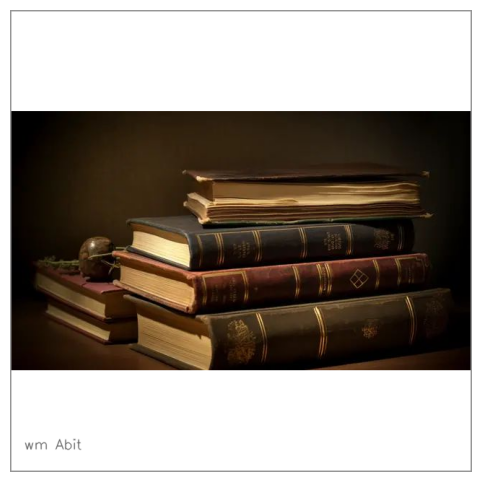

In [ ]:
def thumbnail_marketplace(image_path, nama_toko):
    img = cv.imread(image_path)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # Sisi persegi diambil dari nilai maksimal antara tinggi atau lebar
    sisi = max(h, w)

    # Kanvas persegi berwarna putih
    canvas = np.full((sisi, sisi, 3), 255, dtype=np.uint8)

    # Menghitung titik tengah agar gambar berada tepat di tengah
    y_offset = (sisi - h) // 2
    x_offset = (sisi - w) // 2
    canvas[y_offset:y_offset+h, x_offset:x_offset+w] = img_rgb

    # Menambahkan garis tepi/bingkai abu-abu tipis agar sama dengan gambar contoh
    cv.rectangle(canvas, (0, 0), (sisi-1, sisi-1), (150, 150, 150), 2)

    # Menambahkan teks nama toko proporsional di sudut kiri bawah
    font_scale = sisi / 1000
    thickness = max(1, int(sisi / 400))
    cv.putText(canvas, nama_toko, (int(sisi * 0.03), int(sisi * 0.95)),
               cv.FONT_HERSHEY_SIMPLEX, font_scale, (100, 100, 100), thickness, cv.LINE_AA)

    return canvas

# --- CARA MENAMPILKAN HASIL SESUAI MODUL ---
hasil_thumbnail = thumbnail_marketplace('/content/drive/MyDrive/PCVK/an antique stack of books has been placed in front of a dark background.jpg', 'wm Abit')

plt.figure(figsize=(6, 6))
plt.imshow(hasil_thumbnail)
# Mematikan sumbu angka agar persis seperti gambar contoh
plt.axis('off')
plt.show()